# 잠재 요인 협업 필터링
* 사용자-아이템 평점 매트릭스 속에 숨어 있는 잠재 요인을 추출해 추천 예측을 할 수 있는 기법
* 행렬 분해(matirx factorization) : 대규모 다차원 행렬에 SVD 등 차원 감소 기법으로 분해하는 과정에서 잠재요인 추출
* 다차원 희소 행렬인 사용자-아이템 행렬 데이터 -> 저차원 밀집 행렬의 '사용자-잠재요인 행렬'과 '아이템-잠재요인 행렬의 전치행렬(잠재요인-아이템)'로 분해 -> 두 행렬의 내적 -> 새로운 예측 사용자-아이템 평점 행렬 데이터 만듦 -> 사용자가 아직 평점을 부여하지 않는 아이템 대한 예측 평점 생성
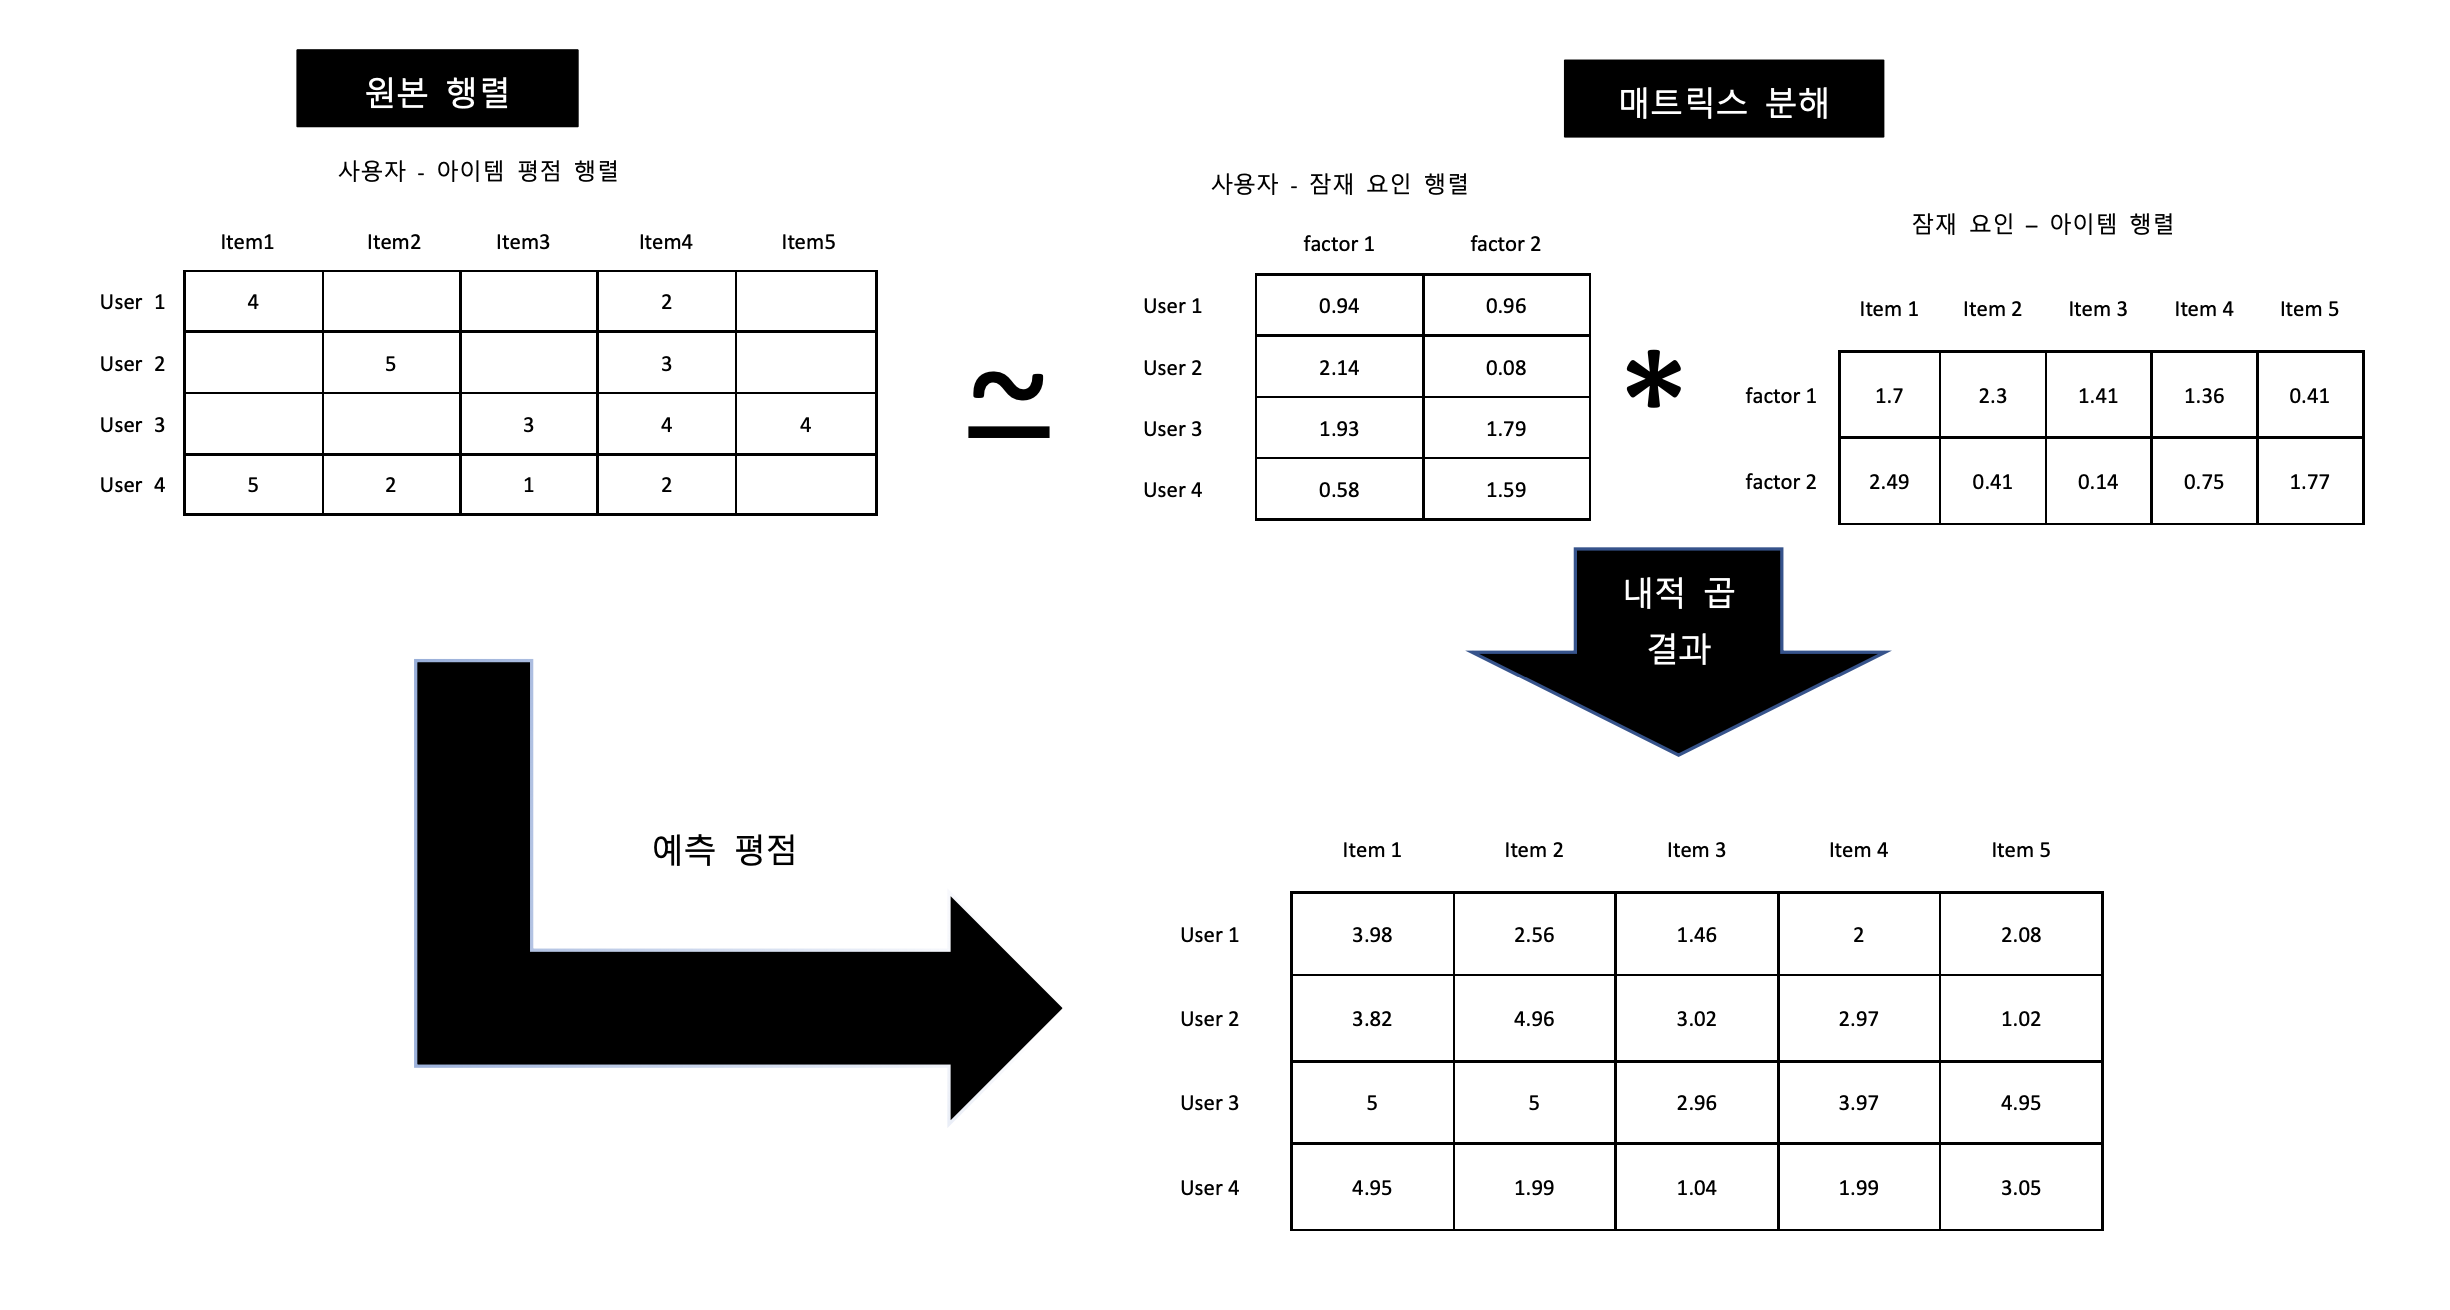
* 행렬 예시
  * 행렬R : 사용자의 아이템에 대한 평점 R(u, i) / 사용자 아이디 u / 아이템 아이디 i
  * 행렬P : 액션 선호도 factor1 / 로맨스 선호도 factor2
  * 행렬Q : 액션 요소값 factor1 / 로맨스 요소값 factor2
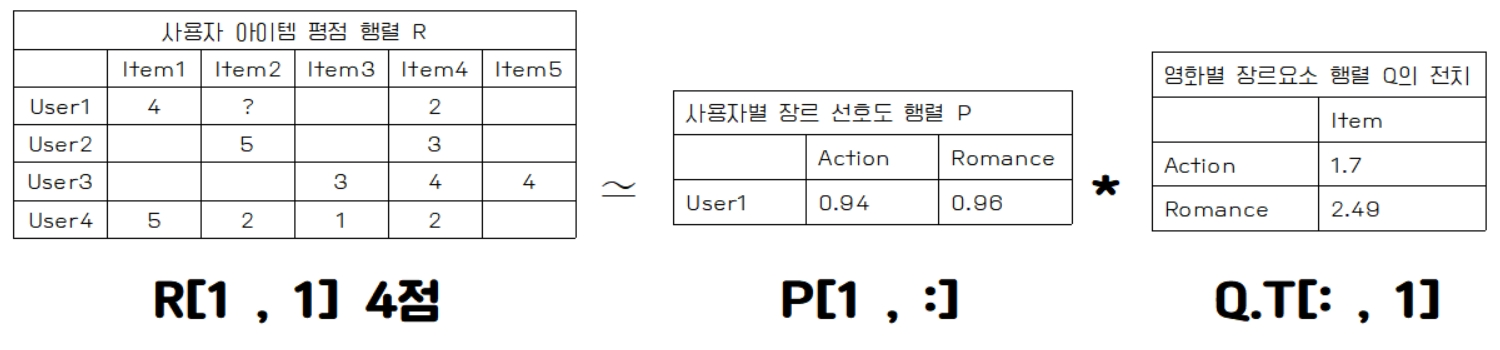
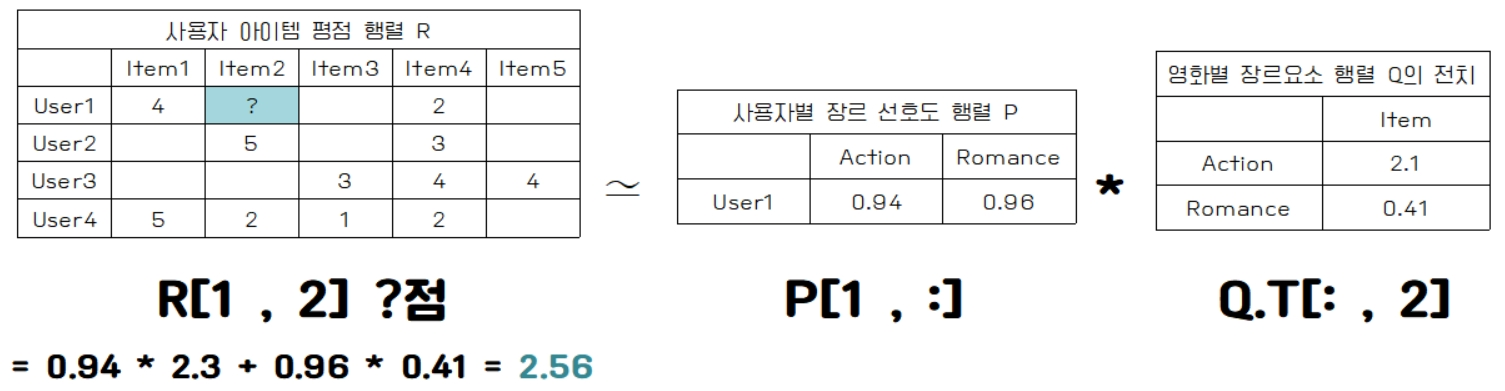

# 행렬 분해의 이해
* 다차원의 행렬을 저차원의 행렬로 분해하는 기법
* SVD(singular Vector Decomposition), NMF(Non-negetive matirx factorization) 등
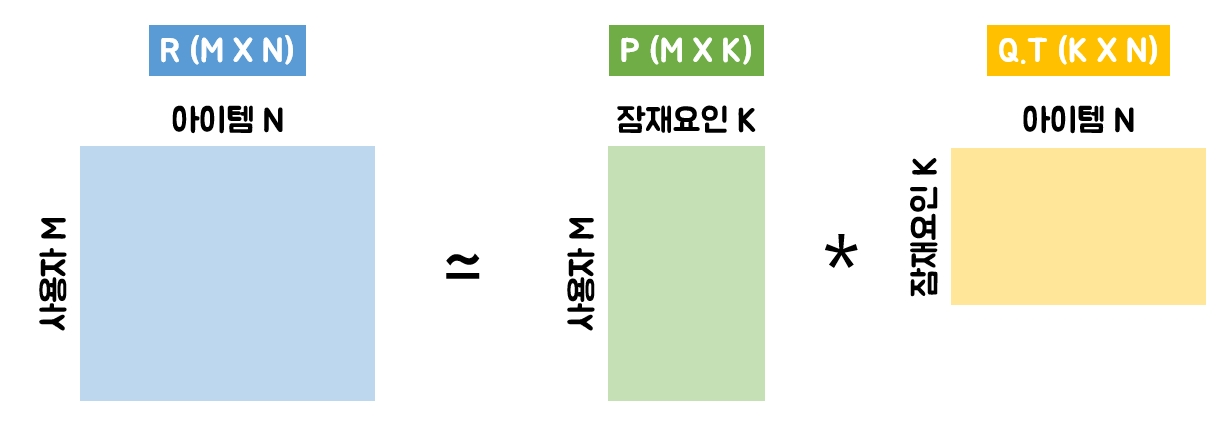
* R = P * Q.T
  * M : 총 사용자수
  * N : 총 아이템 수
  * K : 잠재요인 차원 수
* R 행렬의 u행 사용자와 i열 아이템 위치의 평점 데이터를 r(u, i)라 하자
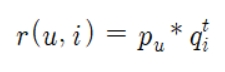
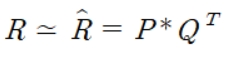
* R 행렬을 P와 Q 행렬로 분해 -> 주로 SVD 이용하나, NaN 값이 없는 행렬에만 적용 가능 -> 확률적 경사 하강법 / ALS(Alternating Least Squares) 이용해 SVD 수행

# 확률적 경사 하강법을 이용한 행렬 분해
* Stochastic Gradient Descnet(SGD)
* 경사 하강법의 한 종류
* SGD를 이용한 행렬 분해 방법
  * P와 Q 행렬로 계산된 예측 R 행렬값이, 실제 R 행렬값과 가장 최소의 오류를 가질 수 있도록, 반복적인 비용함수 최적화로, P와 Q를 유추하는 것
  * 절차
    * P, Q를 임의의 값 가진 행렬로 설정
    * P * Q.T해 예측 R행렬을 계산하고, 실제 R 행렬과의 오류값 계산
    * 오류값을 최소화할 수 있도록 P, Q행렬을 적절한 값으로 업데이트
    * 만족할만한 오류값을 가질 때까지 2, 3작업을 반복하며 P, Q 값을 업데이트해 근사화
* 실제&예측값의 오류 최소화 & L2규제 고려한 비용함수식
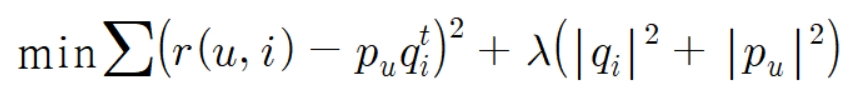
* 사용자-아이템 평점 행렬에서 행렬 분해를 위해 단순히 예측 오류값의 최소화 & 학습시 과적합 피하기 위해 규제를 반영한 비용함수 적용
* 비용함수 최소화 하려 새롭게 업데이트되는 값
  * pu : P 행렬의 사용자 u행 벡터
  * pit : Q행렬의 아이템 i의 전치벡터
  * e(u, i) : u행 i열에 위치한 실제 행렬과 예측 행렬값 차이 오류
  * eta : SGD 학습률
  * gamma : L2 규제 계수
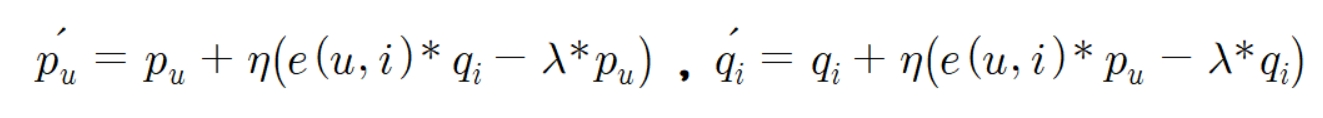

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

#원본행렬 생성, 분해행렬 초기화
R = np.array([[4, np.NaN, np.NaN, 2, np.NaN],
            [np.NaN, 5, np.NaN, 3, 1],
            [np.NaN, np.NaN, 3, 4, 4],
            [5, 2, 1, 2, np.NaN]])
num_users, num_items = R.shape
K=3

#P, Q 행렬의 크기 지정, 정규 분포 가진 임의의 값으로 입력
np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_items, K))

#실제와 예측 행렬의 오차 구하는 함수. 
def get_rmse(R, P, Q, non_zeros):
    error = 0
    full_pred_matrix = np.dot(P, Q.T)
    #실제 R행렬에서 널이 아닌 값의 위치 인덱스 추출 -> 실제 R행렬과 예측 행렬의 RMSE추출
    x_non_zero_idx = [non_zero[0] for non_zero in non_zeros]
    y_non_zero_idx = [non_zero[1] for non_zero in non_zeros]
    R_non_zeros = R[x_non_zero_idx, y_non_zero_idx]
    full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_idx, y_non_zero_idx]
    mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse = np.sqrt(mse)
    
    return rmse


###SGD 기반으로 행렬 분해 수행
#R에서 널값을 제외한 데이터의 행렬 인덱스 추출
non_zeros = [(i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] > 0]

steps = 1000 #SGD를 반복해서 업데이트할 횟수
learning_rate = 0.01 #SGD 학습률
r_lambda = 0.01 #L2 규제 계수

#SGD기법으로 P, Q행렬 계속 업데이트
for step in range(steps):
    for i, j, r in non_zeros:
        eij = r - np.dot(P[i, :], Q[j, :].T) #오류값
        #규제 반영한 SGD 업데이트 공식 적용
        P[i, :] = P[i, :] + learning_rate * (eij * Q[j, :] - r_lambda * P[i, :])
        Q[j, :] = Q[j, :] + learning_rate * (eij * P[i, :] - r_lambda * Q[j, :])
    rmse = get_rmse(R, P, Q, non_zeros)
    if(step%50)==0:
        print('### iteration step : ', step, "  rmse : ", rmse)

### iteration step :  0   rmse :  3.2388050277987723
### iteration step :  50   rmse :  0.4876723101369648
### iteration step :  100   rmse :  0.1564340384819247
### iteration step :  150   rmse :  0.07455141311978046
### iteration step :  200   rmse :  0.04325226798579314
### iteration step :  250   rmse :  0.029248328780878973
### iteration step :  300   rmse :  0.022621116143829466
### iteration step :  350   rmse :  0.019493636196525135
### iteration step :  400   rmse :  0.018022719092132704
### iteration step :  450   rmse :  0.01731968595344266
### iteration step :  500   rmse :  0.016973657887570753
### iteration step :  550   rmse :  0.016796804595895633
### iteration step :  600   rmse :  0.01670132290188466
### iteration step :  650   rmse :  0.01664473691247669
### iteration step :  700   rmse :  0.016605910068210026
### iteration step :  750   rmse :  0.016574200475705
### iteration step :  800   rmse :  0.01654431582921597
### iteration step :  850   rmse :  0.01651375177

In [8]:
pred_matrix = np.dot(P, Q.T)
print('예측 행렬 : \n', np.round(pred_matrix, 3))

예측 행렬 : 
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]
